# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch     
from torchvision import datasets, transforms 
from torchvision.datasets import ImageFolder  
from torch.utils.data import ConcatDataset    
from torch.utils.data import DataLoader       
from torch.utils.data import random_split     
import torch.nn as nn                 
import torch.optim as optim
import torch.nn.functional as F 

from torchvision.transforms import GaussianBlur

# Image Proccessing Pipeline

In [2]:
mnist_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dida_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x),  # invert only DIDA
    transforms.Normalize((0.1307,), (0.3081,))
])

# Original Datasets

In [3]:
dida_data = ImageFolder(root='../datasets/dida/70000', transform=dida_transform)
mnist_data = datasets.MNIST(root='../datasets/data', train=True, download=True, transform=mnist_transform)
mnist_test = datasets.MNIST(root='../datasets/data', train=False, download=True, transform=mnist_transform)
# scanned_data = ImageFolder(root='../predicted_images/', transform=dida_transform)

# Splitting and Combining Datasets

In [4]:
generator = torch.Generator().manual_seed(42)

dida_train, dida_test = random_split(dida_data, [0.8, 0.2], generator=generator)
train_data = ConcatDataset([mnist_data, dida_train])
test_data = ConcatDataset([mnist_test, dida_test])


# Data Loaders

In [5]:
loaders = {
    'train': DataLoader(train_data, batch_size=100, shuffle=True),
    'test': DataLoader(test_data, batch_size=100, shuffle=True)
}

# Visualization

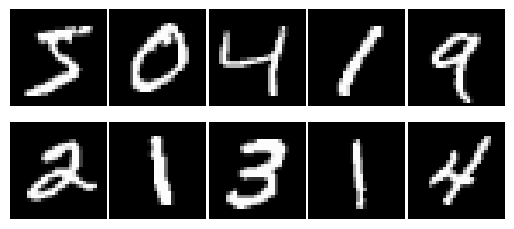

In [6]:

fig, axes = plt.subplots(2, 5, figsize=(5, 2.5))  # small grid
for i, ax in enumerate(axes.flat):
    img, label = mnist_data[i]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout(pad=0.2)
plt.show()

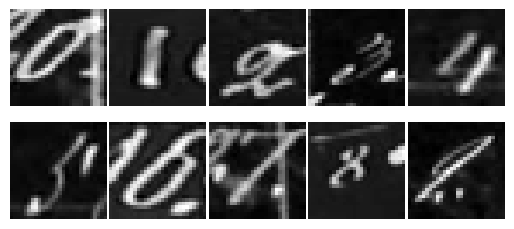

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(5, 2.5))  # small grid
incremenet = 0

for i, ax in enumerate(axes.flat):
    img, label = dida_data[incremenet]
    incremenet += 7000
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout(pad=0.2)
plt.show()

# Neural Network Model (CNN)

In [8]:

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.dropout1 = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        conv1_output = self.conv1(x)
        pooled1 = F.max_pool2d(conv1_output, 2)
        x = F.relu(pooled1)
        conv2_output = self.conv2(x)
        dropout_output = self.dropout1(conv2_output)
        pooled2 = F.max_pool2d(dropout_output, 2)
        x = F.relu(pooled2)
        x = x.view(-1, 320)
        fc1_output = self.fc1(x)
        x = F.relu(fc1_output)
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        
        return x

# Initalizing model on GPU else CPU

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

# Optimizer

In [10]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store training metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Loss Function

In [11]:
criterion = nn.CrossEntropyLoss()

# Training Function


In [12]:
def train(epoch):
    
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += data.size(0)

        if batch_idx % 20 == 0:
            print('[Epoch: {} {}/{} ({:.0f}%)] [Loss: {:.6f}]'.format(
                epoch,
                batch_idx * len(data),
                len(loaders['train'].dataset),
                100. * batch_idx / len(loaders['train']),
                loss.item()))
    
    # Calculate average loss and accuracy for the epoch
    avg_loss = running_loss / total
    accuracy = 100. * correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    return avg_loss, accuracy

# Testing Function

In [13]:
def test():

    model.eval()
    
    test_loss = 0.0  
    correct = 0       
    total = 0          
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            batch_size = data.size(0)
            loss = criterion(output, target)
            test_loss += loss.item() * batch_size
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += batch_size

    test_loss /= total
    accuracy = 100. * correct / total
    
    test_losses.append(test_loss)
    test_accuracies.append(accuracy)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss,                   
        correct,                      
        total,                        
        accuracy))
    
    return test_loss, accuracy

# Training Loop

In [14]:
for epoch in range(1, 11):  # Epochs 1 through 10
    train_loss, train_acc = train(epoch)
    test_loss, test_acc = test()

print("Completed")

[Epoch: 1 0/116000 (0%)] [Loss: 2.325096]
[Epoch: 1 2000/116000 (2%)] [Loss: 2.231306]
[Epoch: 1 4000/116000 (3%)] [Loss: 2.112530]
[Epoch: 1 6000/116000 (5%)] [Loss: 1.668933]
[Epoch: 1 8000/116000 (7%)] [Loss: 1.499579]
[Epoch: 1 10000/116000 (9%)] [Loss: 1.381669]
[Epoch: 1 12000/116000 (10%)] [Loss: 1.245891]
[Epoch: 1 14000/116000 (12%)] [Loss: 1.157026]
[Epoch: 1 16000/116000 (14%)] [Loss: 1.372519]
[Epoch: 1 18000/116000 (16%)] [Loss: 1.273564]
[Epoch: 1 20000/116000 (17%)] [Loss: 0.967467]
[Epoch: 1 22000/116000 (19%)] [Loss: 0.944662]
[Epoch: 1 24000/116000 (21%)] [Loss: 1.017956]
[Epoch: 1 26000/116000 (22%)] [Loss: 0.952640]
[Epoch: 1 28000/116000 (24%)] [Loss: 1.027660]
[Epoch: 1 30000/116000 (26%)] [Loss: 0.938412]
[Epoch: 1 32000/116000 (28%)] [Loss: 0.900840]
[Epoch: 1 34000/116000 (29%)] [Loss: 1.329398]
[Epoch: 1 36000/116000 (31%)] [Loss: 0.958953]
[Epoch: 1 38000/116000 (33%)] [Loss: 1.029476]
[Epoch: 1 40000/116000 (34%)] [Loss: 0.816565]
[Epoch: 1 42000/116000 (36%

# Saving Model

In [16]:
torch.save(model.state_dict(), "../models/model.pth") # Saves the models state for safley running weights